https://github.com/4GeeksAcademy/naive-bayes-project-tutorial/blob/main/solution.ipynb

In [3]:
import re
import numpy as np
import pandas as pd
import missingno as msno
from sklearn.feature_extraction.text import CountVectorizer #https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from missforest import MissForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import shap
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import RobustScaler

# **0. CONTEXTO Y CARGA DATOS**

[Fuente: https://github.com/4GeeksAcademy/random-forest-project-tutorial/blob/main/README.es.md](https://github.com/4GeeksAcademy/naive-bayes-project-tutorial/blob/main/README.es.md)

Descripción de variables: 

- package_name. Nombre de la aplicación móvil (categórico)
- review. Comentario sobre la aplicación móvil (categórico)
- polarity. Variable de clase (0 o 1), siendo 0 un comentario negativo y 1, positivo (categórico numérico)

Descripción del proyecto:

Los modelos Naive Bayes son muy útiles cuando queremos analizar sentimientos, clasificar textos en tópicos o recomendaciones, ya que las características de estos desafíos cumplen muy bien con los supuestos teóricos y metodológicos del modelo.

En este proyecto practicarás con un conjunto de datos para crear un clasificador de reseñas de la tienda de Google Play.


In [4]:
#Cargamos la base de datos en crudo
df=pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/naive-bayes-project-tutorial/main/playstore_reviews.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   package_name  891 non-null    object
 1   review        891 non-null    object
 2   polarity      891 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 21.0+ KB


In [5]:
df.head()

,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0


In [6]:
# Eliminamos package_name
df.drop(columns="package_name", inplace=True)

# **1. PREPROCESAMIENTO DE DATOS**

## 1.1. Verificar valores

### 1.1.1. Unicos

In [7]:
#Valores unicos por cada columna
unicos=df.nunique()
print("No hay columnas con valores únicos" if sum(unicos==1)==0 else "Hay columnas con valores únicos")

No hay columnas con valores únicos


### 1.1.2. Eliminación de filas y columnas duplicadas

In [8]:
#Indice
dup_fil=df.duplicated().sum()
print("No hay filas duplicadas" if dup_fil==0 else "Hay filas duplicadas")

No hay filas duplicadas


In [9]:
#Trasponemos las columnas para verificar que toda la fila (variable) no sea igual a otra
dup_col=df.T.duplicated(keep=False).sum()
print("No hay variables exactamente iguales" if dup_col==0 else "Hay variables exactamente iguales")

No hay variables exactamente iguales


## 1.2. Verificar missing values

In [10]:
# Columnas columnas con más de un 15% de valores faltantes
missing=df.isna().mean()*100
missing[missing>15]

Series([], dtype: float64)

<Axes: >

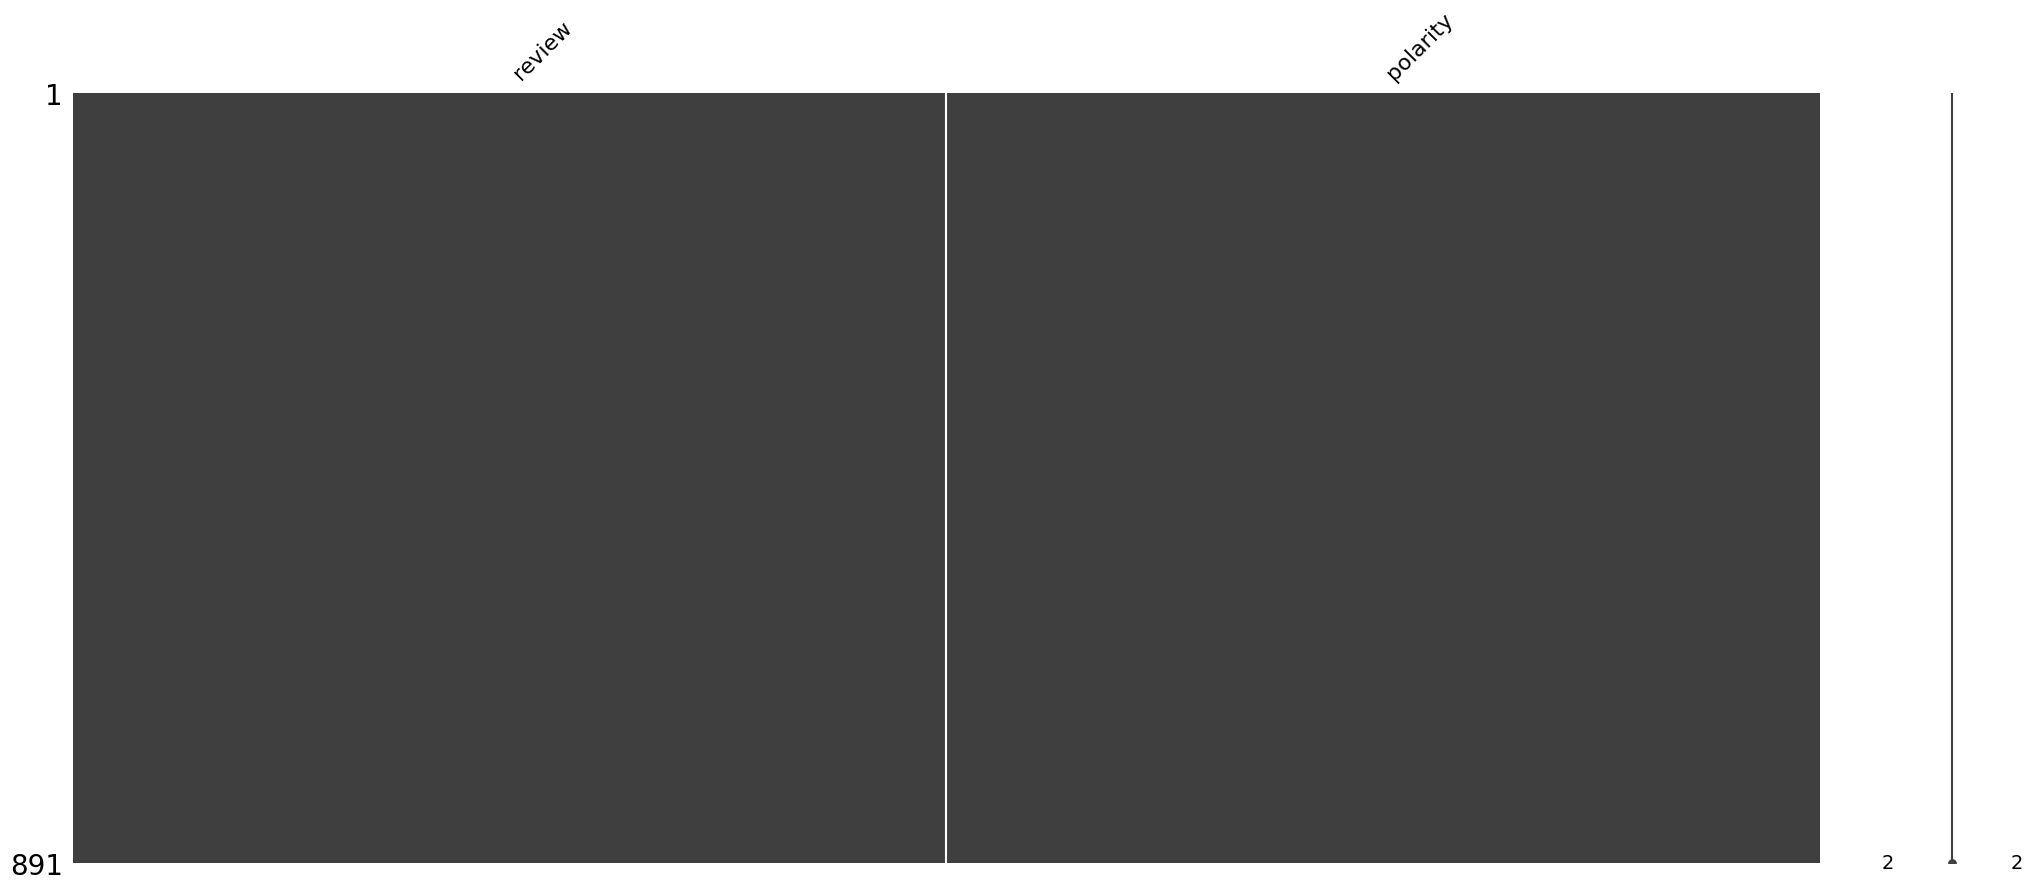

In [11]:
# Gráficamente
msno.matrix(df)

## 1.3. División Train-Test

In [12]:
# Definimos variables
##Strip: Limpiamos las columnas de espacios antes y depués del texto
##Lower: minúscula
X=df["review"].str.strip().str.lower()
y=df["polarity"]

# Dividimos los datos en conjuntos de entrenamiento y testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 1.4. Vectorización ``review``

Esta variable contiene la reseña completa de la aplicación. En este caso, aplicaremos ``CountVectorizer()`` para extraer un conteo matricial por cada palabra observada en al menos una fila. Para aislar lo máximo posible la base de datos train, el conjuto de palabras posibles será definido en train a través de ``.fit()``

In [ ]:
# CONFIGURACIÓN DEL VECTORIZADOR
## Función para eliminar letras repetidas dentro de uan palabra
def limpieza(text):
    """Elimina 3 o más repeticiones de una letra (ej. 'gooddd' -> 'good')."""
    text = re.sub(r'([a-zA-Z])\1{2,}', r'\1\1', text)
    return text

## Intanciamos el método
vectorizer=CountVectorizer(
    stop_words='english', #Elimina 'the', 'is', 'and', 'but', etc.
    token_pattern=r'\b[a-zA-Z]{2,}\b', #Limita a palabras de 3 o más letras
    preprocessor=limpieza, #Aplica la función anterior
    min_df=3, #Elimina palabras que solo aparecen en 1 o 2 veces (errores ortograficos)
    decode_error='ignore',  #Ignora caracteres que no se pueden decodificar (problemas de codificación)
    strip_accents='unicode') #Elimina signos de puntuacion (ej. 'é' a 'e')

In [14]:
# ENTRENAMOS Y APLICAMOS EN TRAIN
#Definimos conjunto de palabras posibles y aplicamos en train
vec = vectorizer.fit_transform(X_train)
# Configuramos como df
col=vectorizer.get_feature_names_out().tolist()
## Accedemos a los valores entrenados
X_train_vec=pd.DataFrame(vec.toarray(), ## Cargamos matriz vectorizada
                         columns=col, ## Cargamos columnas de la matriz
                         index=X_train.index) ## Mantenemos indice
X_train_vec.head(3)

,ability,able,access,account,accounts,action,active,actually,add,added,...,write,writing,wrong,wtf,wth,xperia,year,years,yes,youtube
331,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
733,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
382,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [15]:
# ENTRENAMOS Y APLICAMOS EN TEST
#Definimos conjunto de palabras posibles y aplicamos en train
vec = vectorizer.transform(X_test)
# Configuramos como df
col=vectorizer.get_feature_names_out().tolist()
## Accedemos a los valores entrenados
X_test_vec=pd.DataFrame(vec.toarray(), ## Cargamos matriz vectorizada
                         columns=col, ## Cargamos columnas de la matriz
                         index=X_test.index) ## Mantenemos indice
X_test_vec.head(3)

,ability,able,access,account,accounts,action,active,actually,add,added,...,write,writing,wrong,wtf,wth,xperia,year,years,yes,youtube
709,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
439,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
840,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# **2. Algoritmos**

## 2.1. GaussianNB

https://scikit-learn.org/stable/modules/naive_bayes.html#gaussian-naive-bayes

In [22]:
np.array(X_train_vec)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(712, 914))

In [23]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

bayes = GaussianNB().fit(np.array(X_train_vec), y_train)
y_pred = bayes.predict(np.array(X_test_vec))
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.73      0.79       126
           1       0.53      0.74      0.62        53

    accuracy                           0.73       179
   macro avg       0.70      0.73      0.71       179
weighted avg       0.77      0.73      0.74       179



## 2.2. MultinomialNB

https://scikit-learn.org/stable/modules/naive_bayes.html#multinomial-naive-bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

bayes = MultinomialNB().fit(X_train_vec, y_train)
y_pred = bayes.predict(X_test_vec)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86       126
           1       0.65      0.75      0.70        53

    accuracy                           0.80       179
   macro avg       0.77      0.79      0.78       179
weighted avg       0.82      0.80      0.81       179



## 2.3. BernoulliNB

https://scikit-learn.org/stable/modules/naive_bayes.html#bernoulli-naive-bayes

In [18]:
from sklearn.naive_bayes import BernoulliNB

bayes = BernoulliNB().fit(X_train_vec, y_train)
y_pred = bayes.predict(X_test_vec)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.82      0.85       126
           1       0.63      0.75      0.69        53

    accuracy                           0.80       179
   macro avg       0.76      0.79      0.77       179
weighted avg       0.81      0.80      0.80       179



# **3. Optimización hiperparámetros**